# Decision Tree Pruning (Toy Example)

This notebook demonstrates:
- Overfitting in decision trees
- Cost-complexity pruning
- Selecting the best tree using cross-validation


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score

np.random.seed(0)

## Step 1: Generate toy data

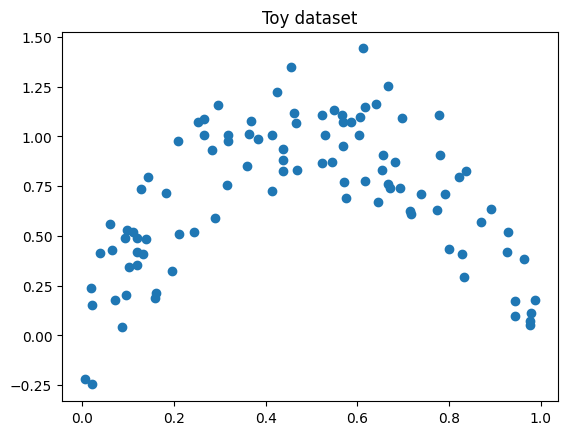

In [2]:
X = np.sort(np.random.rand(100, 1), axis=0)
y = np.sin(3 * X).ravel() + np.random.normal(scale=0.2, size=100)

plt.scatter(X, y)
plt.title("Toy dataset")
plt.show()

## Step 2: Fit a large (overfitted) tree

In [3]:
tree = DecisionTreeRegressor(random_state=0)
tree.fit(X, y)

DecisionTreeRegressor(random_state=0)

## Step 3: Visualize overfitting

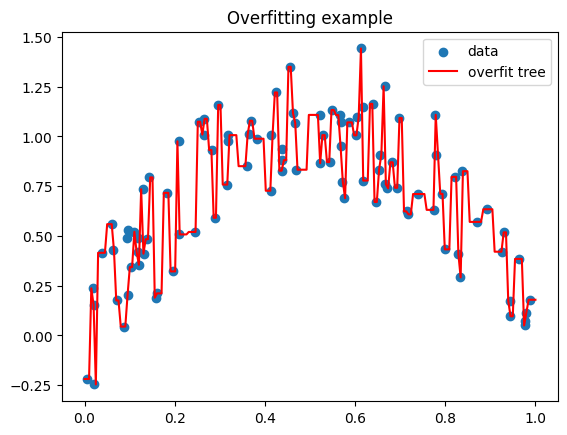

In [4]:
X_test = np.linspace(0, 1, 200).reshape(-1, 1)
y_pred = tree.predict(X_test)

plt.scatter(X, y, label="data")
plt.plot(X_test, y_pred, color="red", label="overfit tree")
plt.legend()
plt.title("Overfitting example")
plt.show()

## Step 4: Get pruning path

In [5]:
path = tree.cost_complexity_pruning_path(X, y)
alphas = path.ccp_alphas
print("Number of alphas:", len(alphas))

Number of alphas: 67


## Step 5: Train trees for different alpha

In [6]:
trees = []
for alpha in alphas:
    t = DecisionTreeRegressor(random_state=0, ccp_alpha=alpha)
    t.fit(X, y)
    trees.append(t)

## Step 6: Visualize pruning effect

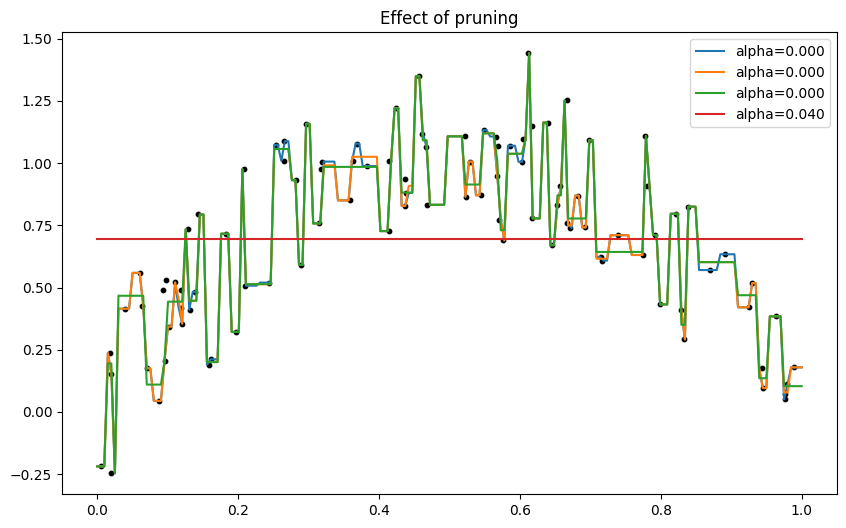

In [7]:
plt.figure(figsize=(10,6))
for i in [0, len(trees)//4, len(trees)//2, -1]:
    y_pred = trees[i].predict(X_test)
    plt.plot(X_test, y_pred, label=f"alpha={alphas[i]:.3f}")

plt.scatter(X, y, color="black", s=10)
plt.legend()
plt.title("Effect of pruning")
plt.show()

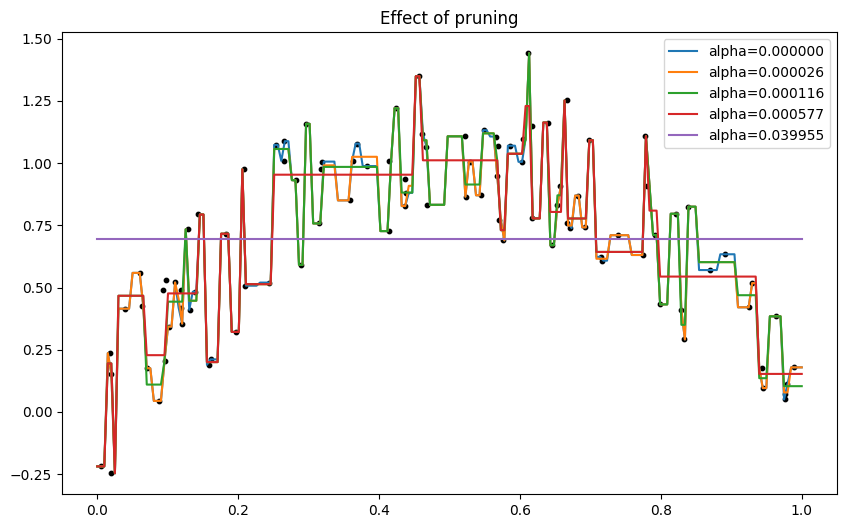

In [12]:
plt.figure(figsize=(10,6))

indices = np.linspace(0, len(trees)-1, 5, dtype=int)

for i in indices:
    y_pred = trees[i].predict(X_test)
    plt.plot(X_test, y_pred, label=f"alpha={alphas[i]:.6f}")

plt.scatter(X, y, color="black", s=10)
plt.legend()
plt.title("Effect of pruning")
plt.show()

## Step 7: Cross-validation to select alpha

In [8]:
cv_scores = []
for alpha in alphas:
    t = DecisionTreeRegressor(random_state=0, ccp_alpha=alpha)
    scores = cross_val_score(t, X, y, cv=5, scoring="neg_mean_squared_error")
    cv_scores.append(-scores.mean())

## Step 8: Plot CV error

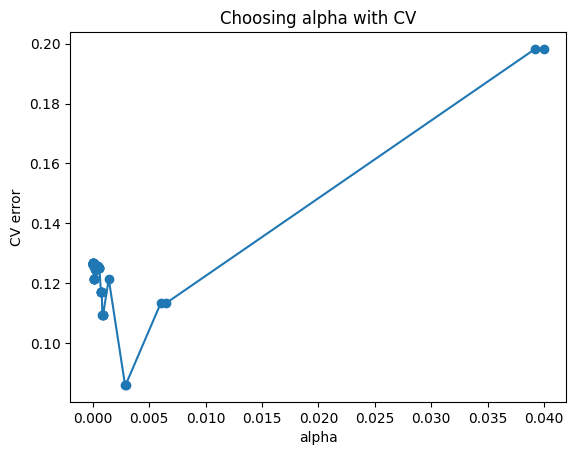

In [9]:
plt.plot(alphas, cv_scores, marker='o')
plt.xlabel("alpha")
plt.ylabel("CV error")
plt.title("Choosing alpha with CV")
plt.show()

## Step 9: Select best model

In [10]:
best_alpha = alphas[np.argmin(cv_scores)]
print("Best alpha:", best_alpha)

best_tree = DecisionTreeRegressor(ccp_alpha=best_alpha)
best_tree.fit(X, y)

Best alpha: 0.002865663183928056


DecisionTreeRegressor(ccp_alpha=np.float64(0.002865663183928056))

## Step 10: Final result

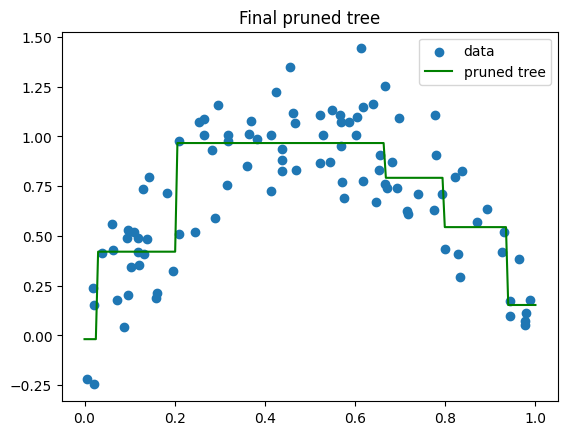

In [11]:
y_best = best_tree.predict(X_test)

plt.scatter(X, y, label="data")
plt.plot(X_test, y_best, color="green", label="pruned tree")
plt.legend()
plt.title("Final pruned tree")
plt.show()